In [18]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import psycopg2
from datetime import datetime
import talib as ta
from scipy.signal import find_peaks



In [20]:


def find_head_and_shoulders(df, lookback=20, tolerance=0.02):
    """
    Detect Head and Shoulders pattern in close prices.
    df: DataFrame with a 'close' column.
    lookback: window to search for local peaks/troughs.
    tolerance: price variation allowed for shoulder symmetry.
    """
    close = df['close']
    patterns = []
    peaks, _ = find_peaks(df['close'], distance=10, prominence=0.5)
    troughs, _ = find_peaks(-df['close'], distance=10, prominence=0.5)


    for i in range(lookback, len(close) - lookback):
        # Find local peak (potential head)
        head = close[i]
        if head == close[i-lookback:i+lookback].max():
            left_window = close[i-lookback:i]
            right_window = close[i+1:i+lookback]

            left_shoulder = left_window.max()
            right_shoulder = right_window.max()
            neckline_left = left_window.min()
            neckline_right = right_window.min()

            # Shoulders roughly same height within tolerance
            if abs(left_shoulder - right_shoulder) / head < tolerance:
                # Neckline slope tolerance
                if abs(neckline_left - neckline_right) / head < tolerance:
                    patterns.append({
                        'index': i,
                        'head': head,
                        'left_shoulder': left_shoulder,
                        'right_shoulder': right_shoulder,
                        'neckline_left': neckline_left,
                        'neckline_right': neckline_right
                    })
    return pd.DataFrame(patterns)


In [19]:
from config import db_conn
conn = db_conn()

symbol = 'BANKNIFTY-I'
from_date = '2025-10-01'
to_date = '2025-11-07'

query = f"""
    SELECT date AT TIME ZONE 'Asia/Kolkata' AS local_time, *
    FROM idata_60min
    WHERE symbol = %s AND date(date) >= %s AND date(date) <= %s
    ORDER BY date ASC;
"""
params = (symbol, from_date, to_date)

cursor = conn.cursor()
cursor.execute(query, params)
rows = cursor.fetchall()
columns = [desc[0] for desc in cursor.description]

df = pd.DataFrame(rows, columns=columns)
df['date'] = df["local_time"]
df.sort_values(by="date", inplace=True)
# df["date"] = pd.to_datetime(df["date"])
df.drop(columns=["local_time", "id"], inplace=True)
numeric_cols = ["open", "high", "low", "close", "volume"]
df[numeric_cols] = df[numeric_cols].astype(float)


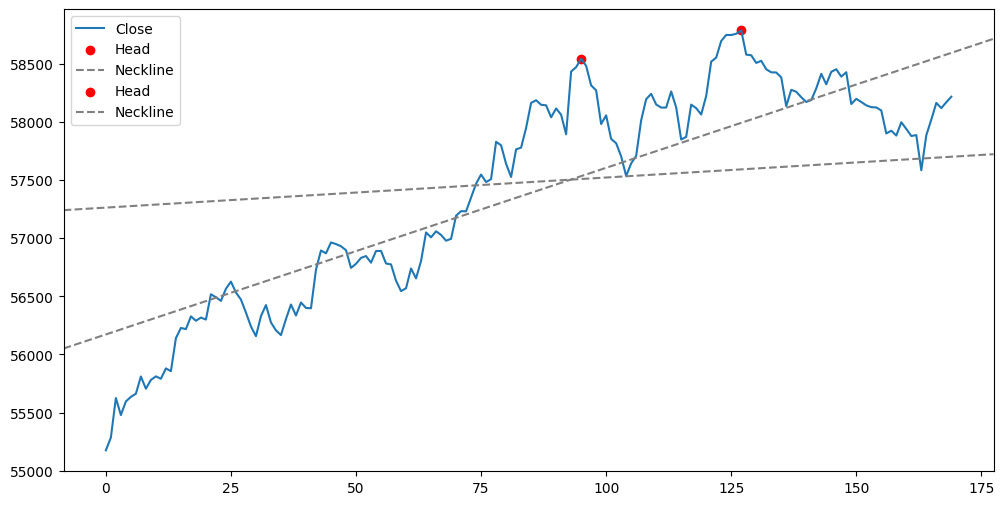

In [17]:
import matplotlib.pyplot as plt

patterns = find_head_and_shoulders(df)

plt.figure(figsize=(12,6))
plt.plot(df['close'], label='Close')

for _, p in patterns.iterrows():
    plt.scatter(p['index'], p['head'], color='red', label='Head')
    plt.axline((p['index']-10, p['neckline_left']),
               (p['index']+10, p['neckline_right']),
               color='gray', linestyle='--', label='Neckline')
plt.legend()
plt.show()
